In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import arviz as az
from pathlib import Path
import pytensor

pytensor.config.mode = "NUMBA"
plt.rcParams["figure.constrained_layout.use"] = True

## Model comparison

In [2]:
hrd_path = Path.cwd().parent.parent / "data" / "hrd.csv"
hrd_df = pd.read_csv(hrd_path, index_col=0, low_memory=False)
participants_list = hrd_df.participant_id.unique()

In [3]:
(
    combined_standard_model,
    combined_weighted_update,
    combined_cardiac_hgf,
    participants,
) = [], [], [], []
for participant_id in participants_list:
    standard = (
        Path().cwd().parent.parent
        / "results"
        / "idata"
        / f"standard_model_session2_{participant_id}.nc"
    ).exists()
    weighted_update = (
        Path().cwd().parent.parent
        / "results"
        / "idata"
        / f"weighted_update_session2_{participant_id}.nc"
    ).exists()
    cardiac_hgf = (
        Path().cwd().parent.parent
        / "results"
        / "idata"
        / f"cardiac_hgf_session2_{participant_id}.nc"
    ).exists()

    if standard & weighted_update & cardiac_hgf:
        combined_standard_model.append(
            az.from_netcdf(
                Path().cwd().parent.parent
                / "results"
                / "idata"
                / f"standard_model_session2_{participant_id}.nc"
            )
        )
        combined_weighted_update.append(
            az.from_netcdf(
                Path().cwd().parent.parent
                / "results"
                / "idata"
                / f"cardiac_hgf_session2_{participant_id}.nc"
            )
        )
        combined_cardiac_hgf.append(
            az.from_netcdf(
                Path().cwd().parent.parent
                / "results"
                / "idata"
                / f"cardiac_hgf_session2_{participant_id}.nc"
            )
        )

        participants.append(participant_id)

In [4]:
standard_idata = az.concat(
    combined_standard_model,
    dim="chain",
)
weighted_update_idata = az.concat(
    combined_weighted_update,
    dim="chain",
)
cardiac_hgf_idata = az.concat(
    combined_cardiac_hgf,
    dim="chain",
)

In [7]:
model_compare = az.compare(
    {
        "standard": standard_idata,
        "weigthed_update": weighted_update_idata,
        "cardiac_hgf": cardiac_hgf_idata,
    },
    var_name="bin",
);

/home/nicolas/git/ComputationalCardioception/.venv/lib/python3.12/site-packages/arviz/stats/stats.py:1045: RuntimeWarning: overflow encountered in exp
  weights = 1 / np.exp(len_scale - len_scale[:, None]).sum(axis=1)
/home/nicolas/git/ComputationalCardioception/.venv/lib/python3.12/site-packages/numpy/_core/_methods.py:52: RuntimeWarning: overflow encountered in reduce
  return umr_sum(a, axis, dtype, out, keepdims, initial, where)
/home/nicolas/git/ComputationalCardioception/.venv/lib/python3.12/site-packages/arviz/stats/stats.py:797: UserWarning: Estimated shape parameter of Pareto distribution is greater than 0.70 for one or more samples. You should consider using a more robust model, this is because importance sampling is less likely to work well if the marginal posterior and LOO posterior are very different. This is more likely to happen with a non-robust model and highly influential observations.
  warnings.warn(
arviz - WARNING - Array contains NaN-value.
/home/nicolas/git/Comp

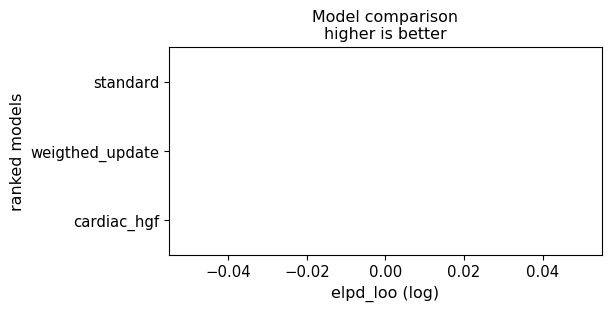

In [8]:
az.plot_compare(model_compare);